# Getting started with `fluidmech`

This tutorial walks through the core of the library: fluid properties, the Reynolds number,
and the three classic pipe-flow problems. Everything is in **SI units**; temperatures are in °C.

In [1]:
try:
    import fluidmech
except ImportError:  # e.g. on Google Colab
    %pip install -q git+https://github.com/ktwyw/fluidmech.git
    import fluidmech
print("fluidmech", fluidmech.__version__)

fluidmech 0.3.0


In [2]:
import matplotlib.pyplot as plt
from fluidmech import Fluid
from fluidmech import pipe_flow as pf
from fluidmech.dimensionless import reynolds, flow_regime

## 1. Fluid properties

`Fluid.water(T)` and `Fluid.air(T, p)` build a fluid from validated correlations. You can also
define any Newtonian fluid directly from its density and viscosity.

In [3]:
water = Fluid.water(20)
oil = Fluid(density=870, dynamic_viscosity=0.035, name="hydraulic oil")
for f in (water, Fluid.air(20), oil):
    print(f"{f.name:<18} rho = {f.density:8.3f} kg/m3   nu = {f.kinematic_viscosity:.3e} m2/s")

water @ 20 degC    rho =  998.234 kg/m3   nu = 1.004e-06 m2/s
air @ 20 degC      rho =    1.204 kg/m3   nu = 1.506e-05 m2/s
hydraulic oil      rho =  870.000 kg/m3   nu = 4.023e-05 m2/s


## 2. Laminar or turbulent?

$$Re = \frac{V D}{\nu}$$

Pipe flow is laminar below $Re \approx 2300$ and fully turbulent above about 4000.

In [4]:
for v in (0.05, 0.2, 1.0):
    re = reynolds(v, 0.05, water.kinematic_viscosity)
    print(f"V = {v:4} m/s in a 50 mm pipe: Re = {re:8.0f} -> {flow_regime(re)}")

V = 0.05 m/s in a 50 mm pipe: Re =     2491 -> transitional
V =  0.2 m/s in a 50 mm pipe: Re =     9965 -> turbulent
V =  1.0 m/s in a 50 mm pipe: Re =    49825 -> turbulent


## 3. Head loss (Type 1 problem)

The Darcy–Weisbach equation, with the friction factor from the Colebrook equation:

$$h_f = f\,\frac{L}{D}\,\frac{V^2}{2g}, \qquad
\frac{1}{\sqrt f} = -2\log_{10}\left(\frac{\varepsilon/D}{3.7} + \frac{2.51}{Re\sqrt f}\right)$$

Minor losses from fittings add $h_m = \sum K \, V^2/2g$.

In [5]:
k_total = pf.MINOR_LOSS_K["sharp_entrance"] + 4 * pf.MINOR_LOSS_K["elbow_90_regular"] + pf.MINOR_LOSS_K["exit"]
r = pf.head_loss(flow_rate=0.02, diameter=0.1, length=200, fluid=water,
                 roughness=pf.ROUGHNESS["commercial_steel"], k_total=k_total)
r

PipeFlowResult(flow_rate=0.02, diameter=0.1, velocity=2.546479089470325, reynolds=253754.35277164186, friction_factor=0.018163856137177022, major_head_loss=12.010680284601435, minor_head_loss=0.8926748957796987, density=998.2336361398824)

In [6]:
print(f"Regime {r.regime}, total head loss {r.total_head_loss:.2f} m, pressure drop {r.pressure_drop/1e3:.1f} kPa")
print(f"Pumping power at 75 % efficiency: {r.pumping_power(0.75)/1e3:.2f} kW")

Regime turbulent, total head loss 12.90 m, pressure drop 126.3 kPa
Pumping power at 75 % efficiency: 3.37 kW


## 4. Flow rate (Type 2) and diameter (Type 3)

In [7]:
q = pf.flow_rate_for_head_loss(8.0, diameter=0.1, length=200, fluid=water, roughness=0.045e-3, k_total=k_total)
d = pf.diameter_for_head_loss(0.02, head_loss_allowed=5.0, length=200, fluid=water, roughness=0.045e-3, k_total=k_total)
print(f"Type 2: Q = {q*1000:.2f} L/s for 8 m of available head")
print(f"Type 3: D = {d*1000:.1f} mm keeps the loss at 5 m -> choose the next standard size up")

Type 2: Q = 15.58 L/s for 8 m of available head
Type 3: D = 121.1 mm keeps the loss at 5 m -> choose the next standard size up


## 5. How head loss depends on diameter

Head loss falls roughly as $D^{-5}$ at constant flow, which is why pipe diameter is the most
important decision in pipeline design.

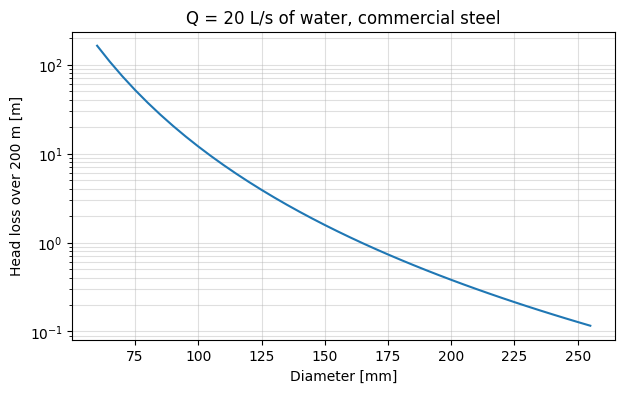

In [8]:
diameters = [0.06 + 0.005 * i for i in range(40)]
losses = [pf.head_loss(0.02, d, 200, water, 0.045e-3).total_head_loss for d in diameters]
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy([d * 1000 for d in diameters], losses)
ax.set_xlabel("Diameter [mm]"); ax.set_ylabel("Head loss over 200 m [m]")
ax.set_title("Q = 20 L/s of water, commercial steel"); ax.grid(True, which="both", alpha=0.4)
plt.show()

## Next steps

* `02_pipe_networks_and_pumps.ipynb` — pumps and whole pipe networks
* `03_open_channel_hydraulics.ipynb` — rivers, canals, weirs and jumps
* `04_compressible_flow.ipynb` — nozzles and shock waves
* The `examples/` folder holds 50 more worked problems.